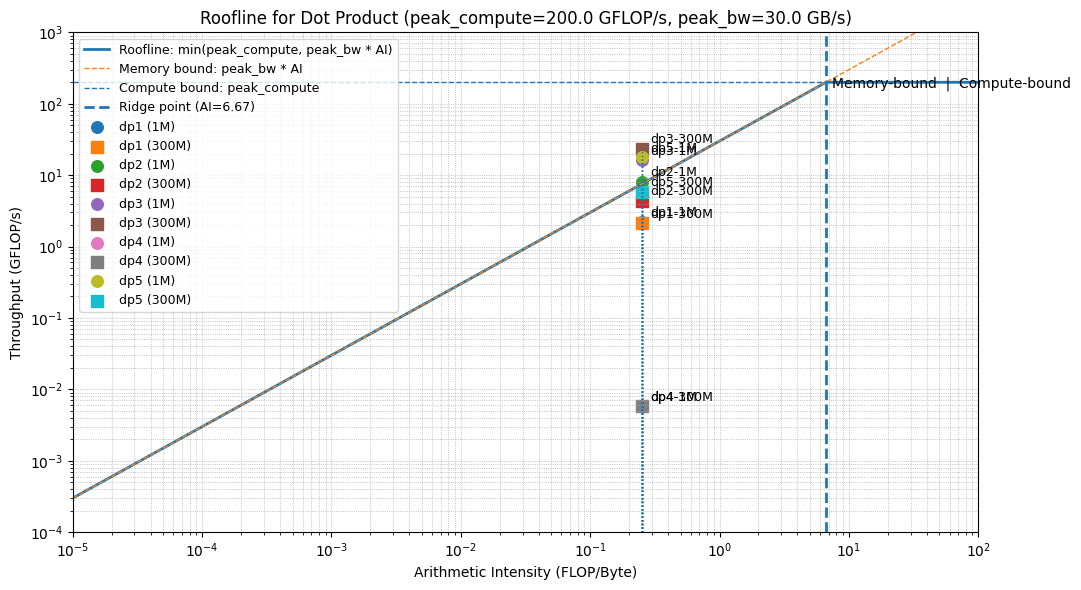

Group       | BW_avg(GB/s) | TP_avg(GFLOP/s) | AI(F/B)    | Roof@AI(GF) | Eff
----------------------------------------------------------------------------------------
dp1-1M     |     8.816667 |       2.204109 |  0.249993 |    7.499803 | 0.29
dp1-300M   |     8.526333 |       2.131534 |  0.249994 |    7.499825 | 0.28
dp2-1M     |    32.438000 |       8.109558 |  0.250002 |    7.500054 | 1.08
dp2-300M   |    17.628667 |       4.407153 |  0.249999 |    7.499976 | 0.59
dp3-1M     |    64.756000 |      16.189066 |  0.250001 |    7.500031 | 2.16
dp3-300M   |    93.277000 |      23.319282 |  0.250000 |    7.500010 | 3.11
dp4-1M     |     0.023129 |       0.005782 |  0.249998 |    7.499951 | 0.00
dp4-300M   |     0.023053 |       0.005763 |  0.249998 |    7.499943 | 0.00
dp5-1M     |    71.348646 |      17.837161 |  0.250000 |    7.500000 | 2.38
dp5-300M   |    23.439850 |       5.859963 |  0.250000 |    7.500000 | 0.78


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Data: bandwidth in GB/s, throughput in GFLOP/s (already /1e9)
# ============================================================
data = {
    # "dp1-1M": {
    #     "bandwidth": [8.813, 8.810, 8.827],
    #     "throughput": [2.203316508243, 2.202383048053, 2.206626351088],
    # },
    "dp1-300M": {
        "bandwidth": [8.527, 8.531, 8.521],
        "throughput": [2.131707833537, 2.132723519242, 2.130169708288],
    },

    # "dp2-1M": {
    #     "bandwidth": [33.267, 32.406, 31.641],
    #     "throughput": [8.316857984202, 8.101549553407, 7.910267570021],
    # },
    "dp2-300M": {
        "bandwidth": [17.945, 17.384, 17.557],
        "throughput": [4.486365082982, 4.345899156210, 4.389193536310],
    },

    # "dp3-1M": {
    #     "bandwidth": [68.878, 64.817, 60.573],
    #     "throughput": [17.219487700611, 16.204339573992, 15.143370312737],
    # },
    "dp3-300M": {
        "bandwidth": [101.495, 88.186, 90.150],
        "throughput": [25.373780741202, 22.046455710917, 22.537609438546],
    },

    # "dp4-1M": {
    #     "bandwidth": [0.023281, 0.022947, 0.023159],
    #     "throughput": [0.005820247513, 0.005736656161, 0.005789732182],
    # },
    "dp4-300M": {
        "bandwidth": [0.022740, 0.023162, 0.023257],
        "throughput": [0.005684956976, 0.005790530016, 0.005814132670],
    },

    # "dp5-1M": {
    #     "bandwidth": [74.484630, 70.605532, 68.955775],
    #     "throughput": [18.621157500311, 17.651383096470, 17.238943872686],
    # },
    "dp5-300M": {
        "bandwidth": [23.901358, 22.801017, 23.617175],
        "throughput": [5.975339620393, 5.700254141694, 5.904293746182],
    },
}

# =========================
# Roofline parameters
# =========================
peak_compute = 200.0   # GFLOP/s
peak_bw = 30.0        # GB/s  (suggested based on your measured ~101 GB/s; set to 30.0 if required)

# =========================
# Plot range (make it larger)
# Log axis cannot start at 0
# =========================
x_min, x_max = 1e-5, 1e2   # Arithmetic Intensity range
y_min, y_max = 1e-4, 1e3   # Throughput range (GFLOP/s)

# =========================
# Helpers: compute averages
# =========================
def avg(vals):
    return float(np.mean(vals))

# Collect averaged points
points = []
for name, v in data.items():
    b = avg(v["bandwidth"])
    t = avg(v["throughput"])
    ai = t / b if b > 0 else np.nan  # FLOP/Byte
    points.append((name, b, t, ai))

# =========================
# Build roofline curve
# =========================
ai_line = np.logspace(np.log10(x_min), np.log10(x_max), 600)
roof_mem = peak_bw * ai_line
roof = np.minimum(roof_mem, peak_compute)

# Ridge point (boundary line)
ridge_ai = peak_compute / peak_bw

# =========================
# Draw
# =========================
plt.figure(figsize=(11, 6))

# Roofline
plt.loglog(ai_line, roof, linewidth=2, label="Roofline: min(peak_compute, peak_bw * AI)")
plt.loglog(ai_line, roof_mem, linestyle="--", linewidth=1, label="Memory bound: peak_bw * AI")
plt.hlines(peak_compute, x_min, x_max, linestyles="--", linewidth=1, label="Compute bound: peak_compute")

# Ridge point boundary (vertical line)
plt.axvline(ridge_ai, linestyle="--", linewidth=2, label=f"Ridge point (AI={ridge_ai:.2f})")

# Optional annotation text near ridge
plt.text(ridge_ai * 1.12, y_max / 6, "Memory-bound  |  Compute-bound", fontsize=10)

# Plot points with vertical AI lines
dp_order = ["dp1", "dp2", "dp3", "dp4", "dp5"]
markers = {"1M": "o", "300M": "s"}  # circle vs square

# For a stable legend (avoid too many duplicates), we’ll label each dp+size once
labeled = set()

for dp in dp_order:
    for size in ["1M", "300M"]:
        key = f"{dp}-{size}"
        if key not in data:
            continue

        b = avg(data[key]["bandwidth"])
        t = avg(data[key]["throughput"])
        ai = t / b

        # Vertical line indicating arithmetic intensity (from y_min up to the point)
        plt.vlines(ai, y_min, t, linestyles=":", linewidth=1)

        label = f"{dp} ({size})"
        show_label = label not in labeled
        if show_label:
            labeled.add(label)

        plt.scatter(ai, t, marker=markers[size], s=70, label=label if show_label else None)
        plt.annotate(key, (ai, t), textcoords="offset points", xytext=(6, 4), fontsize=9)

# Axes, grid, legend
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("Arithmetic Intensity (FLOP/Byte)")
plt.ylabel("Throughput (GFLOP/s)")
plt.title(f"Roofline for Dot Product (peak_compute={peak_compute} GFLOP/s, peak_bw={peak_bw} GB/s)")
plt.grid(True, which="both", linestyle=":", linewidth=0.6)
plt.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.show()

# =========================
# Print summary table
# =========================
print("Group       | BW_avg(GB/s) | TP_avg(GFLOP/s) | AI(F/B)    | Roof@AI(GF) | Eff")
print("-" * 88)
for name, b, t, ai in sorted(points):
    roof_at_ai = min(peak_compute, peak_bw * ai)
    eff = t / roof_at_ai if roof_at_ai > 0 else np.nan
    print(f"{name:<10} | {b:>12.6f} | {t:>14.6f} | {ai:>9.6f} | {roof_at_ai:>11.6f} | {eff:>4.2f}")
